In [15]:
#!pip install albumentations
#!pip install segmentation_models_pytorch

In [16]:

# import numpy as np
# from torch.utils.data import DataLoader, Dataset
# import segmentation_models_pytorch as smp
import albumentations as A
import cv2
from albumentations.pytorch import ToTensorV2


In [17]:
from src.utils.config import load_config
from src.utils.helpers import init_this_notebook, p  #, data_loader  #, load_images_and_masks

cfg = load_config()
init_this_notebook(cfg.SEED)


=== YAML Configuration ===
01: paths:
02:   root: C:\github\Tree-Canopy-Detection
03:   data: src/data
04:   train_images: src/data/train_images
05:   train_images_zip: src/data/train_images.zip
06:   train_masks: src/data/train_masks
07:   eval_images: src/data/evaluation_images
08:   eval_images_zip: src/data/evaluation_images.zip
09:   eval_masks: src/data/eval_masks
10:   models: models
11:   notebooks: notebooks
12:   checkpoint: checkpoints/unet_resnet34_best.pth
13:   best_model: checkpoints/checkpoint_best.pth
14: params:
15:   image_size: 512
16:   num_workers: 0
17:   seed: 42
18:   encoder_name: resnet34
19:   encoder_weights: imagenet
20:   in_channels: 3
21:   classes: 1
22:   batch_size: 8
23:   epochs: 2
24:   learning_rate: 1e-4
25:   best_val_loss: 1.0e9
26:   early_stop_patience: 5
27:   scheduler_factor: 0.5
28:   scheduler_patience: 3
29:   scheduler_verbose: true

Python: 3.12.6 (tags/v3.12.6:a4a2d2b, Sep  6 2024, 20:11:23) [MSC v.1940 64 bit (AMD64)]
Numpy: 1.26.

In [18]:
# ---------------------------------------------------------------
# augmentations and tensor conversion
# ---------------------------------------------------------------
transformer_resize = A.Compose(
    [
        A.Resize(cfg.IMAGE_SIZE, cfg.IMAGE_SIZE),
        ToTensorV2(),
    ]
)

transformer = A.Compose(
    [
        A.Resize(cfg.IMAGE_SIZE, cfg.IMAGE_SIZE),
        #A.LongestMaxSize(max_size=512),
        #A.PadIfNeeded(min_height=512, min_width=512, border_mode=cv2.BORDER_CONSTANT),
        #
        # Geometric
        A.HorizontalFlip(p = 0.5),
        A.VerticalFlip(p = 0.5),
        A.ShiftScaleRotate(shift_limit = 0.1, scale_limit = 0.1, rotate_limit = 15, p = 0.5),
        A.Affine(scale = (0.9, 1.1), rotate = (-15, 15), shear = (-10, 10), p = 0.5),
        #
        # Color and lighting
        A.RandomBrightnessContrast(p = 0.5),
        ##A.HueSaturationValue(p=0.5),
        A.CLAHE(p = 0.5),  # adaptive histogram equalization
        ##A.RGBShift(p=5),
        #
        # Noise and blur
        # A.GaussianBlur(p=0.5),
        ## A.MotionBlur(p=1),
        ##A.GaussNoise(p=5),
        #
        # Distortions
        A.ElasticTransform(0.1),
        A.GridDistortion(p = 0.1),
        A.OpticalDistortion(p = 0.1),
        #
        # Normalization and tensor conversion (always last)
        ### A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)



In [19]:
def load_images_and_masks(image_path, mask_path, transform = None):
    images = [
        f
        for f in image_path.glob("*.*")
        if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".tif", ".tiff"]
    ]

    #images = images[:2]
    data = []
    for i, img_path in enumerate(images, 1):

        image = cv2.imread(img_path)
        if image is None:
            p("Failed to read image", img_path, color = "red")
            return

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path / img_path.name, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            p("Failed to read mask", mask_path, color = "orange")
            return

        if transform:
            augmented = transform(image = image, mask = mask)
            image = augmented["image"]
            mask = augmented["mask"]

        data.append((image, mask))

    p(f"Total (with {"no " if transform is None else ""}transformer)", len(images))
    return data

In [20]:

import torch
import hashlib


class FlexibleSegmentationDataset(torch.utils.data.Dataset):
    def __init__(self, data, to_numpy = False, normalize = True, grayscale = False):
        self.data = data
        self.to_numpy = to_numpy
        self.normalize = normalize
        self.grayscale = grayscale

    def __len__(self):
        return len(self.data)

    # HWC = Height × Width × Channels (NumPy and OpenCV)
    # CHW = Channels × Height × Width (required by PyTorch models)
    def __getitem__(self, idx):
        image, mask = self.data[idx]

        # Handle Albumentations output (might be numpy or torch tensor)
        if isinstance(image, torch.Tensor):
            image = image.float()
            # Albumentations ToTensorV2 already gives CHW, but handle grayscale
            if self.grayscale and image.ndim == 2:
                image = image.unsqueeze(0)
        else:
            # Handle NumPy image
            if self.grayscale and image.ndim == 2:
                image = np.expand_dims(image, axis = -1)  # H x W → H x W x 1
            image = torch.tensor(image).permute(2, 0, 1).float()  # HWC → CHW

        # Handle mask (binary or multi-channel)
        if isinstance(mask, torch.Tensor):
            mask = mask.float()
            # Add channel if mask is HxW
            if mask.ndim == 2:
                mask = mask.unsqueeze(0)
        else:
            mask = torch.tensor(mask).float()
            if mask.ndim == 2:
                mask = mask.unsqueeze(0)  # H → 1 x H x W

        # Normalize image to [0, 1] if the data is still in 0–255 range
        if self.normalize and image.max() > 1.0:
            image /= 255.0
            mask /= 255.0
        # if self.normalize:
        #     image = image.astype("float32") / 255.0
        #     mask = mask.astype("float32") / 255.0
        # # Convert grayscale if needed
        # if self.grayscale and image.ndim == 2:
        #     image = np.expand_dims(image, axis=-1)  # H x W → H x W x 1

        # Convert to numpy
        if self.to_numpy:
            image_np = image.permute(1, 2, 0).cpu().numpy()  # CHW → HWC
            mask_np = mask.squeeze().cpu().numpy()
            return image_np, mask_np

        return image, mask

        # Return NumPy arrays or PyTorch tensors
        # if self.to_numpy:
        #     # Return as NumPy arrays (e.g., for visualization)
        #     if isinstance(image, torch.Tensor):
        #         image = image.permute(1, 2, 0).cpu().numpy()
        #     if isinstance(mask, torch.Tensor):
        #         mask = mask.cpu().numpy()
        #     return image, mask
        # else:
        #     # Convert to PyTorch tensors
        #     image = torch.tensor(image).permute(2, 0, 1).float()  # HWC → CHW
        #     mask = torch.tensor(mask).float().unsqueeze(0)  # H → 1 x H x W
        #     return image, mask

    def get_numpy_item(self, idx):
        """Always return NumPy arrays regardless of to_numpy setting."""
        image, mask = self[idx]
        image = image.permute(1, 2, 0).cpu().numpy()
        mask = mask.squeeze().cpu().numpy()
        return image, mask

        # """Always return NumPy arrays regardless of to_numpy setting."""
        # image, mask = self[idx]
        # if isinstance(image, torch.Tensor):
        #     image = image.permute(1, 2, 0).cpu().numpy()
        # if isinstance(mask, torch.Tensor):
        #     mask = mask.squeeze().cpu().numpy()
        # return image, mask

    @staticmethod
    def hash_image(image):
        """Return MD5 hash for a NumPy array or PyTorch tensor."""
        if isinstance(image, torch.Tensor):
            arr = image.detach().cpu().numpy()
        else:
            arr = np.array(image)
        return hashlib.md5(arr.tobytes()).hexdigest()


In [21]:
from torch.utils.data import DataLoader, random_split

# ---------------------------------------------------------------
# load images and masks
# ---------------------------------------------------------------

# Load originals
original_data = load_images_and_masks(
    cfg.PATHS_TRAIN_IMAGES, cfg.PATHS_TRAIN_MASKS, transform = transformer_resize
)

train_data = []
seen_hashes = set()

# Keep all original images
for image, mask in original_data:
    img_hash = FlexibleSegmentationDataset.hash_image(image)
    train_data.append((image, mask))
    seen_hashes.add(img_hash)

# Generate augmented data
for k in range(1):
    augmented_data = load_images_and_masks(
        cfg.PATHS_TRAIN_IMAGES, cfg.PATHS_TRAIN_MASKS, transform = transformer
    )

    for image, mask in augmented_data:
        img_hash = FlexibleSegmentationDataset.hash_image(image)
        if img_hash not in seen_hashes:
            train_data.append((image, mask))
            seen_hashes.add(img_hash)

# Dataset
train_dataset = FlexibleSegmentationDataset(data = train_data)
p("Total train_dataset records", len(train_dataset))

# Making sure size of all match
for i in range(len(train_dataset)):
    image, mask = train_dataset[i]
    p(f"{i}", f"image {image.shape}, mask {mask.shape}")


Total (with transformer): 150
Total (with transformer): 150
Total train_dataset records: 298

=== DataLoader ===
Total train_loader  records: 30
Total val_loader records: 8


In [ ]:

val_size = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_ds, val_ds = random_split(train_dataset, [train_size, val_size])

# DataLoader
p("DataLoader")
train_loader = DataLoader(train_ds, batch_size = cfg.BATCH_SIZE, shuffle = True)
p("Total train_loader  records", len(train_loader), color = "blue")

val_loader = DataLoader(val_ds, batch_size = cfg.BATCH_SIZE, shuffle = True)
p("Total val_loader records", len(val_loader), color = "blue")



=== index 29 ===


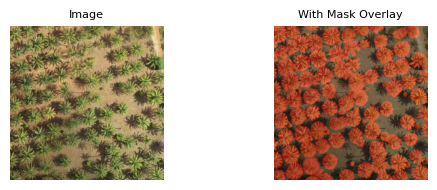

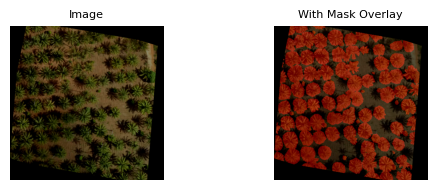


=== index 63 ===


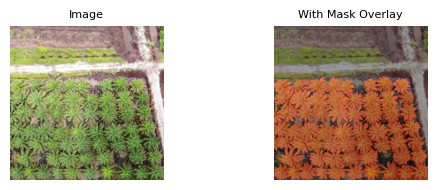

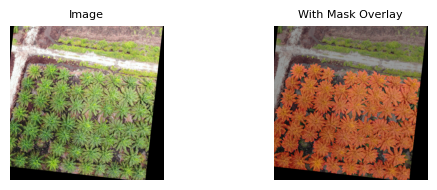

In [22]:
import random


def show_image_with_mask(data, index = 0, alpha = 0.4):
    """
    Display an image and its corresponding mask from an in-memory dataset.
    """
    # Pick random index if needed
    if index == 0:
        index = random.randint(0, len(data) - 1)

    image, mask = data[index]

    # Convert from torch tensor to numpy if needed
    if isinstance(image, torch.Tensor):
        image = image.permute(1, 2, 0).cpu().numpy()
    if isinstance(mask, torch.Tensor):
        mask = mask.cpu().numpy()

    # Handle normalization or scaling
    if image.max() > 1.0:  # probably uint8 0–255
        image_disp = image.astype(np.uint8)
    else:  # probably normalized to 0–1
        image_disp = (image * 255).astype(np.uint8)

    # Normalize mask values to 0–255
    if mask.max() > 1:
        mask_disp = mask.astype(np.uint8)
    else:
        mask_disp = (mask * 255).astype(np.uint8)

    # Create red overlay for mask (in RGB order)
    mask_rgb = np.zeros_like(image_disp)
    mask_rgb[:, :, 0] = mask_disp  # red channel

    # Blend
    overlay = cv2.addWeighted(image_disp, 1 - alpha, mask_rgb, alpha, 0)

    # Plot
    plt.figure(figsize = (6, 2), dpi = 100)
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    if len(data) > 1:
        plt.title(f"Image (index {index})", fontsize = 8)
    else:
        plt.title("Image", fontsize = 8)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title("With Mask Overlay", fontsize = 8)
    plt.axis("off")

    plt.tight_layout()
    plt.show()


def show_transform_samples(image, mask, transform, num_samples = 3, alpha = 0.4):
    """
    Apply an Albumentations transform multiple times and display each result
    using the existing show_image_with_mask function.
    """

    # Convert tensors to numpy if needed
    if isinstance(image, torch.Tensor):
        image = image.permute(1, 2, 0).cpu().numpy()
    if isinstance(mask, torch.Tensor):
        mask = mask.cpu().numpy()

    # Convert to uint8 in case image is in [0,1]
    if image.max() <= 1.0:
        image_disp = (image * 255).astype(np.uint8)
    else:
        image_disp = image.astype(np.uint8)

    if mask.max() <= 1.0:
        mask_disp = (mask * 255).astype(np.uint8)
    else:
        mask_disp = mask.astype(np.uint8)

    show_image_with_mask([(image_disp, mask_disp)], index = 0, alpha = alpha)

    # Apply transformations and visualize
    for i in range(num_samples - 1):
        augmented = transform(image = image_disp, mask = mask_disp)
        aug_img, aug_mask = augmented["image"], augmented["mask"]

        # Use your working display function
        show_image_with_mask([(aug_img, aug_mask)], index = 0, alpha = alpha)


for n in range(2):
    num = random.randint(1, 150)
    p(f"index {num}")
    sample_image, sample_mask = train_data[num]
    show_transform_samples(sample_image, sample_mask, transformer, num_samples = 2)

In [23]:
import segmentation_models_pytorch as smp
import torch

# Model setup
model = smp.Unet(
    encoder_name = "resnet34", encoder_weights = "imagenet", in_channels = 3, classes = 1
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = smp.losses.DiceLoss(mode = "binary")
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = 'min',
    factor = cfg.SCHEDULER_FACTOR,
    patience = cfg.SCHEDULER_PATIENCE,
    #verbose = cfg.SCHEDULER_VERBOSE
)
# Only add 'verbose' if the current PyTorch version supports it
# if "verbose" in torch.optim.lr_scheduler.ReduceLROnPlateau.__init__.__code__.co_varnames:
#     scheduler_args["verbose"] = cfg.SCHEDULER_VERBOSE
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, **scheduler_args)

scaler = torch.cuda.amp.GradScaler()

p(model)



Total parameters: 24,436,369

=== Encoder ===
ResNetEncoder(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_ru

In [26]:

import os

best_val_loss = cfg.BEST_VAL_LOSS
epochs_since_improve = 0
start_epoch = 0

# --- Try resuming training if checkpoint exists ---
if os.path.exists(cfg.PATHS_CHECKPOINT):
    checkpoint = torch.load(cfg.PATHS_CHECKPOINT, map_location = device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optim_state"])
    scheduler.load_state_dict(checkpoint["sched_state"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_loss = checkpoint.get("best_val_loss", cfg.BEST_VAL_LOSS)
    p(f"Resuming from epoch {start_epoch}", color = "purple")

p("EPOCHS", cfg.EPOCHS)
for epoch in range(start_epoch, cfg.EPOCHS):

    # ------------------- TRAINING -------------------
    model.train()
    total_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device, dtype = torch.float32)
        masks = masks.to(device, dtype = torch.float32)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            preds = model(images)
            loss = criterion(preds, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    p(f"Epoch {epoch + 1}", f"Avg Train Loss: {avg_train_loss:.6f}")

    # ------------------- VALIDATION -------------------
    model.eval()
    val_loss = 0.0
    total_iou = 0.0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device, dtype = torch.float32)
            masks = masks.to(device, dtype = torch.float32)

            preds = model(images)
            loss = criterion(preds, masks)
            val_loss += loss.item()

            # Compute IoU (simple binary IoU)
            preds_bin = (torch.sigmoid(preds) > 0.5).float()
            intersection = (preds_bin * masks).sum()
            union = ((preds_bin + masks) > 0).float().sum()
            iou = (intersection + 1e-6) / (union + 1e-6)
            total_iou += iou.item()

    avg_val_loss = val_loss / len(val_loader)
    avg_iou = total_iou / len(val_loader)
    scheduler.step(avg_val_loss)

    p(f"Epoch {epoch + 1}", f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val IoU: {avg_iou:.4f}")

    # ------------------- CHECKPOINTING -------------------
    is_best = avg_val_loss < best_val_loss
    if is_best:
        best_val_loss = avg_val_loss
        epochs_since_improve = 0
        # Save best model separately
        torch.save(
            {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optim_state": optimizer.state_dict(),
                "sched_state": scheduler.state_dict(),
                "best_val_loss": best_val_loss,
            },
            cfg.PATHS_BEST_MODEL,
        )
        p(f"New best model saved at epoch {epoch} with val loss {avg_val_loss:.4f}", color = "green")
    else:
        epochs_since_improve += 1

    # Save checkpoint
    torch.save(
        {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optim_state": optimizer.state_dict(),
            "sched_state": scheduler.state_dict(),
            "best_val_loss": best_val_loss,
        },
        cfg.PATHS_CHECKPOINT
    )

    # ------------------- EARLY STOPPING -------------------
    if epochs_since_improve >= cfg.EARLY_STOP_PATIENCE:
        p(f"No improvement for {cfg.EARLY_STOP_PATIENCE} epochs", "stopping early.", color = "orange")

        break




EPOCHS: 2
Epoch 1: Avg Train Loss: 0.402509
Epoch 0: Train Loss: 0.4025 | Val Loss: 0.4840 | Val IoU: 0.4209

=== New best model saved at epoch 0 with val loss 0.4840 ===
Epoch 2: Avg Train Loss: 0.347486
Epoch 1: Train Loss: 0.3475 | Val Loss: 0.3745 | Val IoU: 0.5371

=== New best model saved at epoch 1 with val loss 0.3745 ===


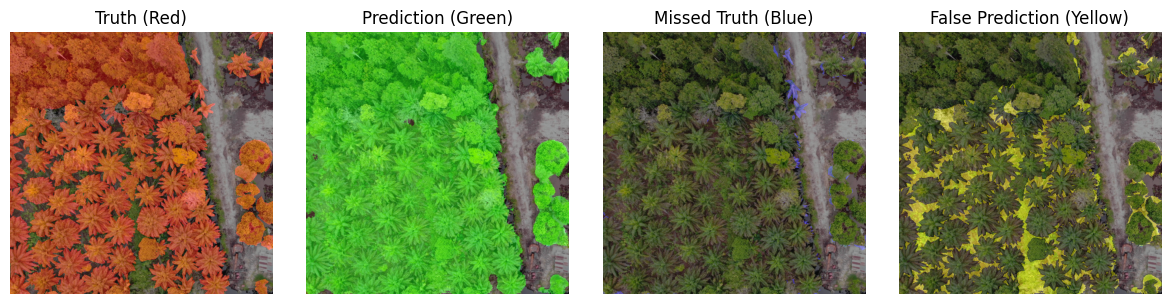

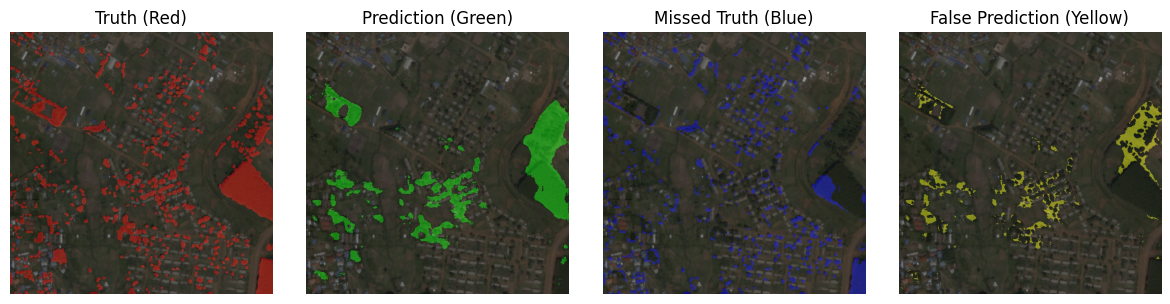

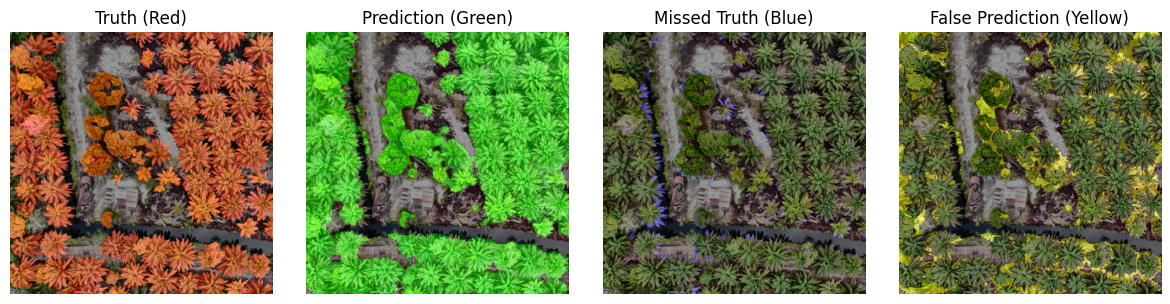

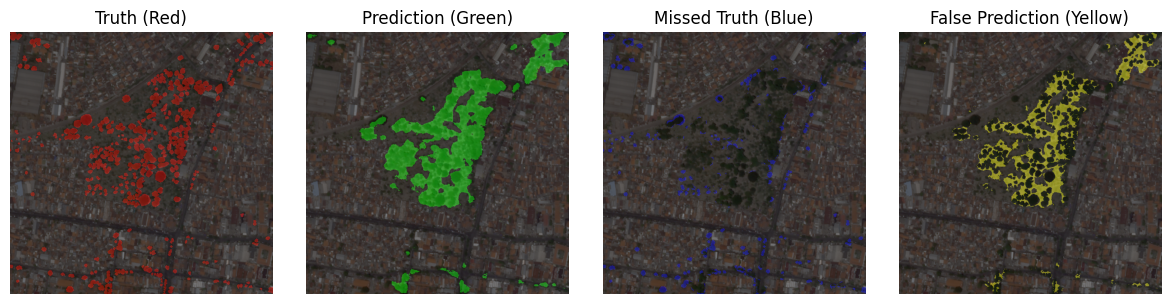

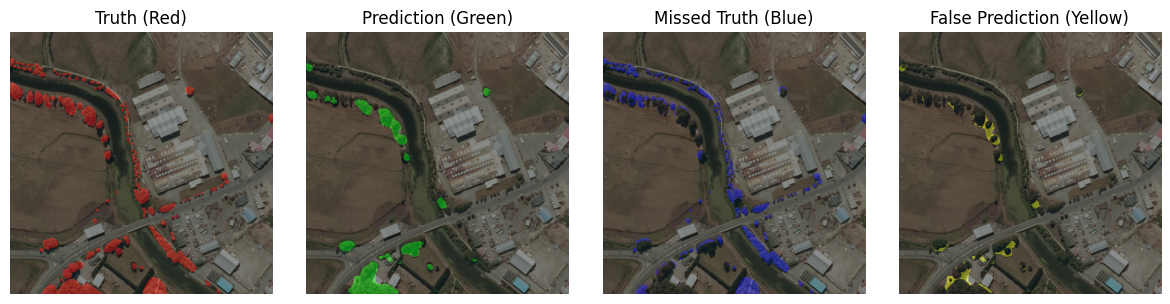

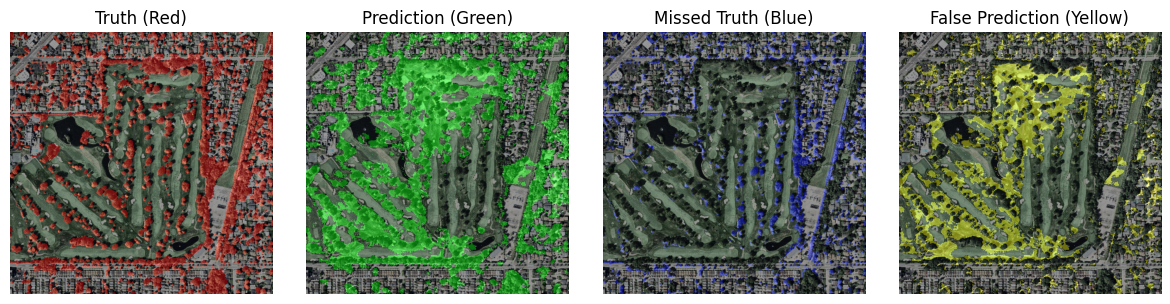

In [29]:

def show_predictions(model, dataset, device, num_samples = 3, alpha = 0.4):
    """
    Display a few random predictions from the dataset using a trained model.
    Includes overlays for:
    - Ground Truth (Red)
    - Prediction (Green)
    - Missed Truth (Blue)
    - False Prediction (Yellow)
    """
    model.eval()
    indices = random.sample(range(len(dataset)), num_samples)

    with torch.no_grad():
        for idx in indices:
            image, mask = dataset[idx]

            # Prepare for model
            image_batch = image.unsqueeze(0).to(device, dtype = torch.float32)
            pred = torch.sigmoid(model(image_batch)).cpu().squeeze().numpy()

            # Convert tensors to numpy
            img_np = image.permute(1, 2, 0).cpu().numpy() if isinstance(image, torch.Tensor) else image
            mask_np = mask.cpu().numpy() if isinstance(mask, torch.Tensor) else mask

            # Normalize images to uint8
            img_disp = (img_np * 255).astype(np.uint8) if img_np.max() <= 1.0 else img_np.astype(np.uint8)
            mask_disp = (mask_np * 255).astype(np.uint8) if mask_np.max() <= 1.0 else mask_np.astype(np.uint8)

            # Prediction binary + scaling
            pred_bin = (pred > 0.5).astype(np.uint8)
            pred_disp = (pred_bin * 255).astype(np.uint8)

            # Overlays
            mask_rgb = np.zeros_like(img_disp)
            mask_rgb[:, :, 0] = mask_disp  # red for truth
            overlay_truth = cv2.addWeighted(img_disp, 1 - alpha, mask_rgb, alpha, 0)

            pred_rgb = np.zeros_like(img_disp)
            pred_rgb[:, :, 1] = pred_disp  # green for prediction
            overlay_pred = cv2.addWeighted(img_disp, 1 - alpha, pred_rgb, alpha, 0)

            # Missed truth (FN): in truth but not in pred
            missed = ((mask_np > 0.5) & (pred_bin == 0)).astype(np.uint8) * 255
            missed_rgb = np.zeros_like(img_disp)
            missed_rgb[:, :, 2] = missed  # blue channel
            overlay_missed = cv2.addWeighted(img_disp, 1 - alpha, missed_rgb, alpha, 0)

            # False predictions (FP): in pred but not in truth
            false_new = ((pred_bin == 1) & (mask_np <= 0.5)).astype(np.uint8) * 255
            false_rgb = np.zeros_like(img_disp)
            false_rgb[:, :, 0] = false_new  # red
            false_rgb[:, :, 1] = false_new  # green  → yellow = red + green
            overlay_false = cv2.addWeighted(img_disp, 1 - alpha, false_rgb, alpha, 0)

            # Plot all four
            plt.figure(figsize = (12, 3), dpi = 100)
            plt.subplot(1, 4, 1)
            plt.imshow(overlay_truth)
            plt.title(f"Truth (Red)")
            plt.axis("off")

            plt.subplot(1, 4, 2)
            plt.imshow(overlay_pred)
            plt.title("Prediction (Green)")
            plt.axis("off")

            plt.subplot(1, 4, 3)
            plt.imshow(overlay_missed)
            plt.title("Missed Truth (Blue)")
            plt.axis("off")

            plt.subplot(1, 4, 4)
            plt.imshow(overlay_false)
            plt.title("False Prediction (Yellow)")
            plt.axis("off")

            plt.tight_layout()
            plt.show()


show_predictions(model, train_ds, device, num_samples = 3)
show_predictions(model, val_ds, device, num_samples = 3)

